In [2]:
#1
import pandas as pd

df = pd.read_csv('catalog_products.csv')

print(f'DataFrame:{df.shape}')
print(df.dtypes)
print(df.isnull().sum())
print(df.head())


DataFrame:(10000, 50)
col_1       str
col_2     int64
col_3     int64
col_4       str
col_5     int64
col_6     int64
col_7       str
col_8     int64
col_9     int64
col_10      str
col_11    int64
col_12    int64
col_13      str
col_14    int64
col_15    int64
col_16      str
col_17    int64
col_18    int64
col_19      str
col_20    int64
col_21    int64
col_22      str
col_23    int64
col_24    int64
col_25      str
col_26    int64
col_27    int64
col_28      str
col_29    int64
col_30    int64
col_31      str
col_32    int64
col_33    int64
col_34      str
col_35    int64
col_36    int64
col_37      str
col_38    int64
col_39    int64
col_40      str
col_41    int64
col_42    int64
col_43      str
col_44    int64
col_45    int64
col_46      str
col_47    int64
col_48    int64
col_49      str
col_50    int64
dtype: object
col_1     0
col_2     0
col_3     0
col_4     0
col_5     0
col_6     0
col_7     0
col_8     0
col_9     0
col_10    0
col_11    0
col_12    0
col_13    0
col_14  

In [7]:
#2
numeric_cols = df.select_dtypes(include=['int64','float64']).columns
text_cols = df.select_dtypes(include=['object','str']).columns

df[numeric_cols] = df[numeric_cols].astype(float)
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

df.dropna(subset=text_cols, inplace=True)
print('final DataFrame:', df.shape)
print('\nDropped spaces in dataframe:',df.isnull().sum().sum())
print(df.dtypes.value_counts())

final DataFrame: (10000, 50)

Dropped spaces in dataframe: 0
float64    33
str        17
Name: count, dtype: int64


In [12]:
#3
import numpy as np

df['total_value'] = df['col_2'] * df['col_3']
df['double_stock'] = df['col_3'] * 2
df['log_price'] = np.log(df['col_2'])

new_columns = ['col_2','col_3','total_value','double_stock','log_price']
display(df[new_columns].head())

,col_2,col_3,total_value,double_stock,log_price
0,762.0,303.0,230886.0,606.0,6.635947
1,190.0,34.0,6460.0,68.0,5.247024
2,711.0,2.0,1422.0,4.0,6.566672
3,484.0,362.0,175208.0,724.0,6.182085
4,733.0,195.0,142935.0,390.0,6.597146


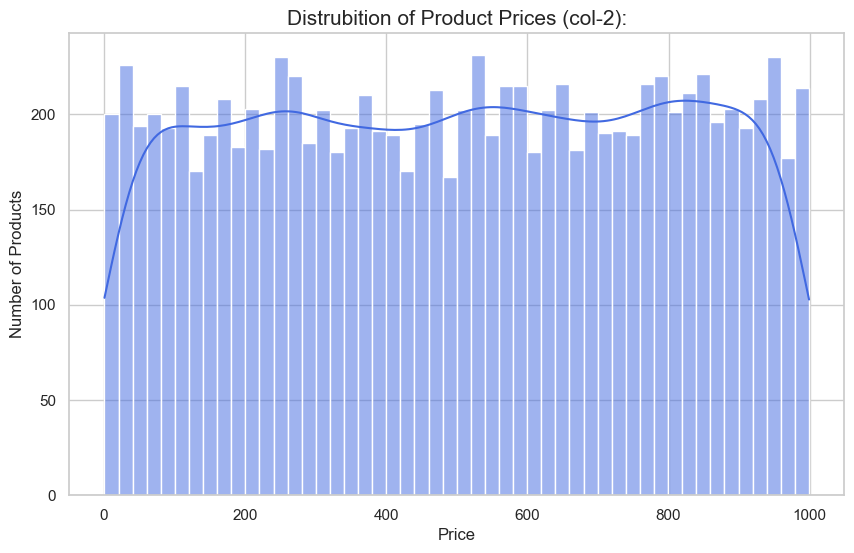

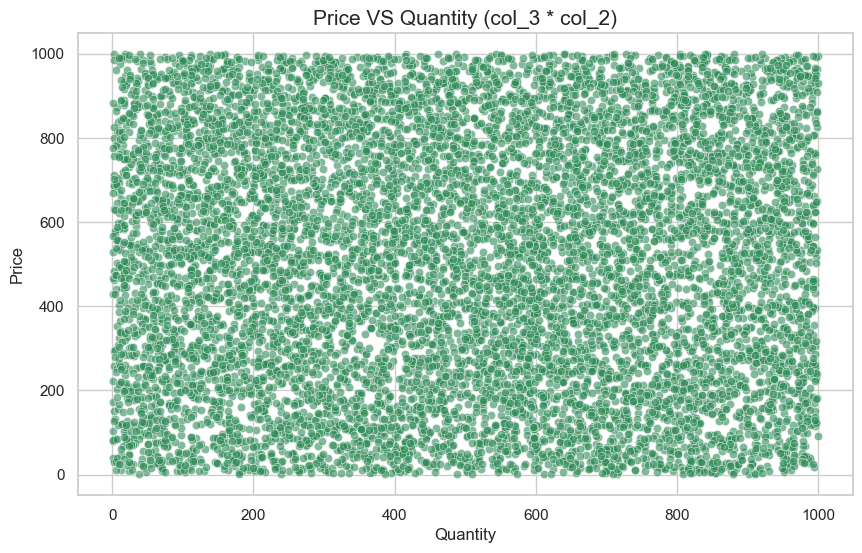

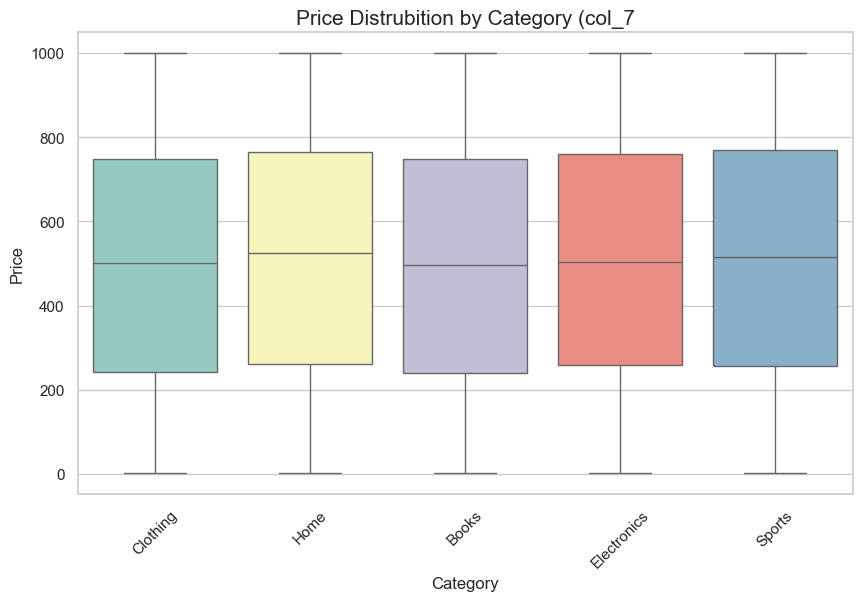

In [22]:
#4
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style='whitegrid')

plt.figure(figsize=(10,6))
sns.histplot(df['col_2'], bins=50, kde=True, color='royalblue')
plt.title('Distrubition of Product Prices (col-2):', fontsize=15)
plt.xlabel('Price', fontsize=12)
plt.ylabel('Number of Products', fontsize=12)
plt.show()

plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x='col_3', y='col_2', alpha=0.6, color='seagreen')
plt.title('Price VS Quantity (col_3 * col_2)', fontsize=15)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.show()

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='col_7', y='col_2', hue='col_7', palette='Set3')
plt.title('Price Distrubition by Category (col_7', fontsize=15)
plt.xlabel('Category', fontsize=12)
plt.ylabel('Price', fontsize=12)
plt.xticks(rotation=45)
plt.show()

In [29]:
#5
mean_price = df['col_2'].mean()
std_price = df['col_2'].std()

upper = mean_price - 3*std_price
lower = mean_price + 3*std_price

anomalies = df[(df['col_2'] < lower) | (df['col_2'] > upper)].copy()
df = df[(df['col_2'] >= lower) & (df[ 'col_2' ] <= upper)]
print(f'Number of anomalies found and separetad: {len(anomalies)}')
print(f'After: {df.shape}')

Number of anomalies found and separetad: 0
After: (0, 53)


In [30]:
#6
import pandas as pd

df = pd.get_dummies(df, drop_first=True , dtype=int)

print('---Categorical Encoding---')
print(f'New DataFrame shape: {df.shape}')

---Categorical Encoding---
New DataFrame shape: (0, 36)
